# Taller 6: Morfología matemática

## Cargue y visualice la imagen meb.png.

In [1]:
PATH = './imagenes/'

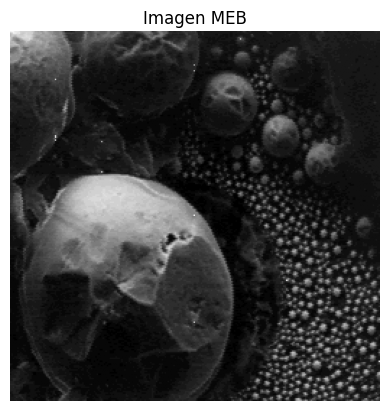

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen_meb = cv2.imread(PATH + 'MEB.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(imagen_meb, cmap='gray')
plt.title('Imagen MEB')
plt.axis('off')
plt.show()

## Utilizando una máscara cuadrada de 3x3, calcule el gradiente morfológico de esta imagen.

In [3]:
from scipy.ndimage import morphological_gradient

mgimage = morphological_gradient(imagen_meb, size=(3,3))

In [5]:
print('La dimensión de la imagen de gradiente morfológico es:', mgimage.shape)

La dimensión de la imagen de gradiente morfológico es: (256, 256)


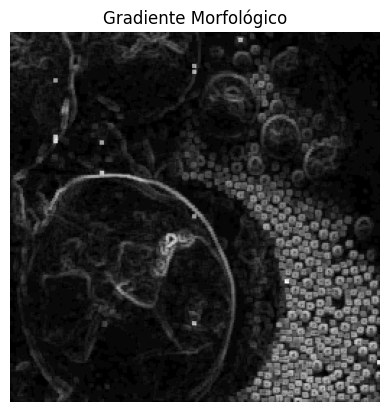

In [6]:
plt.imshow(mgimage, cmap='gray')
plt.title('Gradiente Morfológico')
plt.axis('off')
plt.show()

## Genere la imagen de la norma del gradiente de la imagen meb.png con el operador de Sobel (ver Taller 3). Compare los resultados obtenidos (gradiente morfológico vs. norma del gradiente con Sobel). Puede efectuar una expansión del contraste sobre las dos imágenes obtenidas para visualizar mejor el resultado.

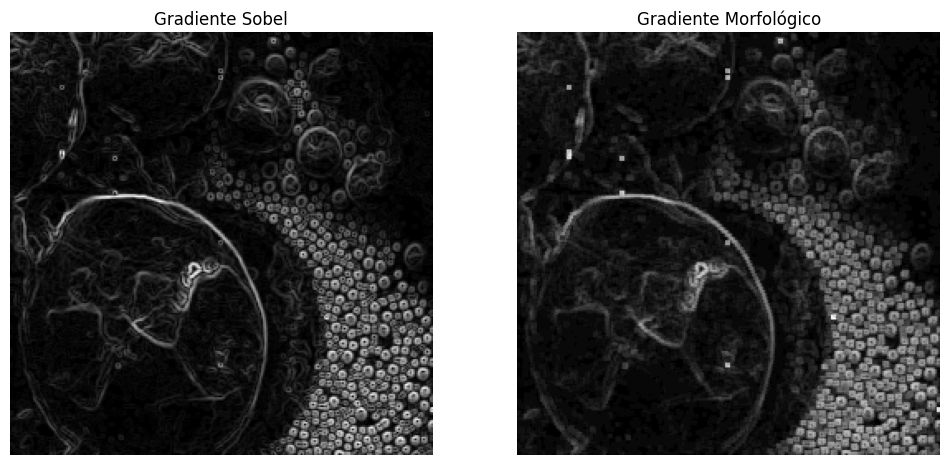

In [7]:
from skimage.filters import sobel

def expansion_contraste(imagen):
    """Expande el contraste de la imagen al rango [0, 255]"""
    min_val = imagen.min()
    max_val = imagen.max()
    imagen_expandida = ((imagen - min_val) / (max_val - min_val) * 255).astype(np.uint8)
    return imagen_expandida

imagen_sobel = sobel(imagen_meb)
imagen_sobel_exp = expansion_contraste(imagen_sobel)
mgimage_exp = expansion_contraste(mgimage)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(imagen_sobel_exp, cmap='gray')
axes[0].set_title('Gradiente Sobel')
axes[0].axis('off')
axes[1].imshow(mgimage_exp, cmap='gray')
axes[1].set_title('Gradiente Morfológico')
axes[1].axis('off')
plt.show()

El gradiente morfológico detecta bordes basándose en diferencia entre dilatación y erosión. Podemos ver en la comparación que da bordes más gruesos y menos definidos que el gradiente de Sobel, que es un operador de detección de bordes basado en derivadas. El gradiente morfológico puede ser más robusto a ruido, pero puede perder detalles finos en los bordes.

## Repita la operación 3 empleando la misma máscara, pero SIN utilizar el operador de gradiente morfológico (créelo con los operadores de dilatación y de erosión, precedidos por un filtrado mediano). ¿Cómo es el resultado obtenido?

Iniciamos aplicando el filtrado mediano.

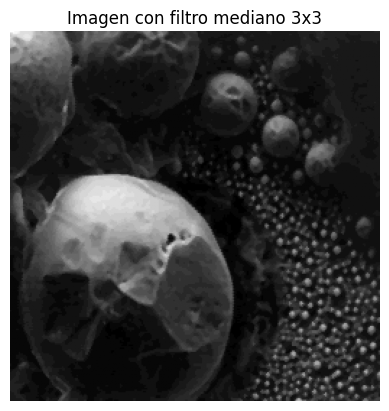

In [8]:
from skimage.morphology import dilation, erosion, square
from scipy.ndimage import median_filter

imagen_filtrada = median_filter(imagen_meb, size=3)

plt.imshow(imagen_filtrada, cmap='gray')
plt.title('Imagen con filtro mediano 3x3')
plt.axis('off')
plt.show()

Calculamos la dilatación y erosión usando como elemento estructurante a un cuadrado de 3x3. Visualizamos el resultado.

/tmp/ipykernel_30442/1742645717.py:2: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  elemento_estructurante = square(3)


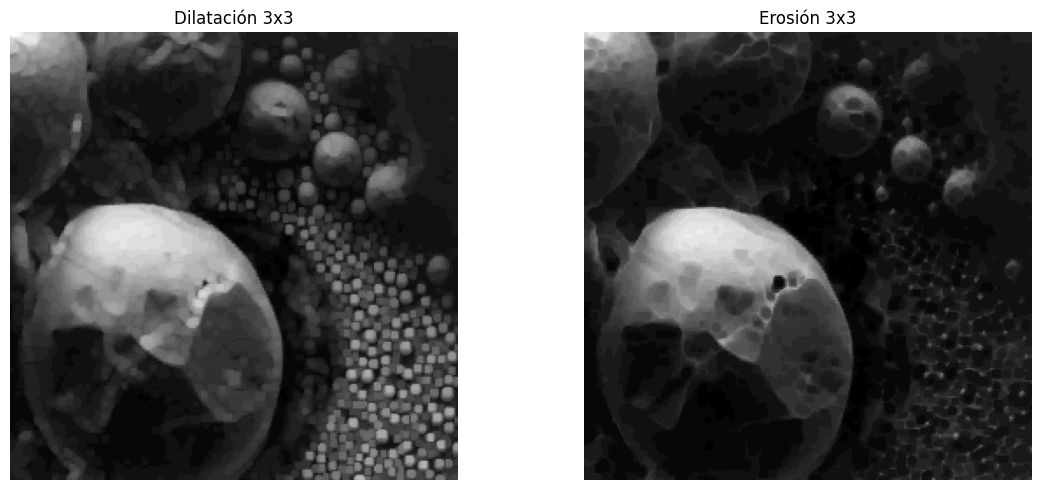

In [ ]:
elemento_estructurante = square(3)

imagen_dilatada = dilation(imagen_filtrada, elemento_estructurante)
imagen_erosionada = erosion(imagen_filtrada, elemento_estructurante)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(imagen_dilatada, cmap='gray')
axes[0].set_title('Dilatación 3x3')
axes[0].axis('off')

axes[1].imshow(imagen_erosionada, cmap='gray')
axes[1].set_title('Erosión 3x3')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Calculamos el gradiente morfológico manual (dilatación - erosión).

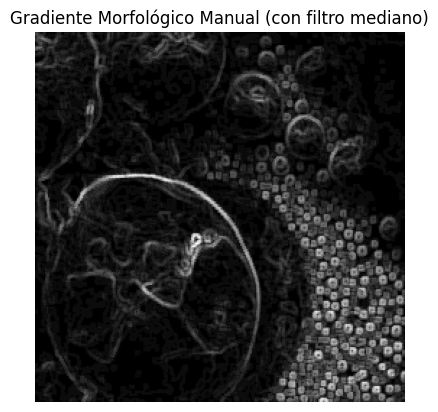

In [12]:
gradiente_manual = imagen_dilatada.astype(np.int16) - imagen_erosionada.astype(np.int16)
gradiente_manual = np.abs(gradiente_manual).astype(np.uint8)

plt.imshow(gradiente_manual, cmap='gray')
plt.title('Gradiente Morfológico Manual (con filtro mediano)')
plt.axis('off')
plt.show()

Comparamos el Gradiente directo vs Manual con filtro mediano

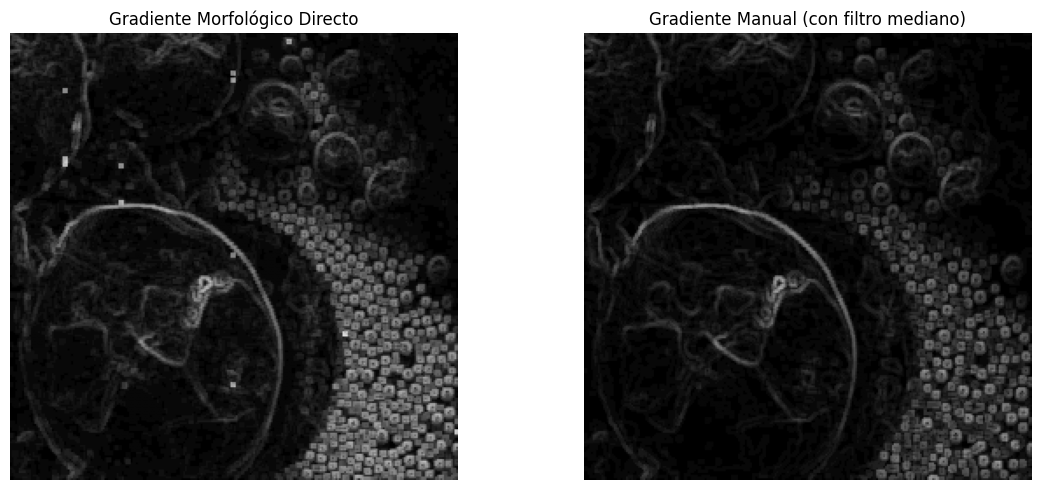

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(mgimage, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Gradiente Morfológico Directo')
axes[0].axis('off')

axes[1].imshow(gradiente_manual, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Gradiente Manual (con filtro mediano)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

**Conclusiones:**

- El filtro de mediana hace que el gradiente manual sea más suave y con menos ruido que el gradiente directo.
- El filtro de mediana elimina ruido de tipo sal y pimienta antes de calcular el gradiente, se nota sobretodo la presencia de ruido tipo sal en el gradiente directo.
- Obtenemos un mejor resultado con el cálculo manual acompañado del filtro de mediana.